In [175]:
import pandas as pd

df = pd.read_csv("../a_Outlier dection and removal using percentile/bhp.csv")

In [176]:
df.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250


In [177]:
min_threshold, max_threshold = df.price_per_sqft.quantile([0.001, 0.999])

In [178]:
df = df[(df.price_per_sqft < (max_threshold)) & (df.price_per_sqft >min_threshold)]
df.shape

(13172, 7)

In [179]:
df.describe()

,total_sqft,bath,price,bhk,price_per_sqft
count,13172.000000,13172.000000,13172.000000,13172.000000,13172.000000
mean,1537.861049,2.690100,111.591865,2.799651,6663.653735
std,967.123711,1.337026,145.372047,1.291130,4141.020700
min,250.000000,1.000000,8.000000,1.000000,1379.000000
25%,1100.000000,2.000000,50.000000,2.000000,4271.000000
50%,1274.500000,2.000000,71.550000,3.000000,5438.000000
75%,1670.000000,3.000000,120.000000,3.000000,7311.000000
max,30400.000000,40.000000,3600.000000,43.000000,50349.000000


# Using 4 standard deviations to remove outliers

In [180]:
mean = df.price_per_sqft.mean()
std = df.price_per_sqft.std()

In [181]:
lower_limit = mean - 4*std
upper_limit = mean + 4*std

In [182]:
df1 = df[(df.price_per_sqft> lower_limit) & (df.price_per_sqft < upper_limit)]
df1.shape

(13047, 7)

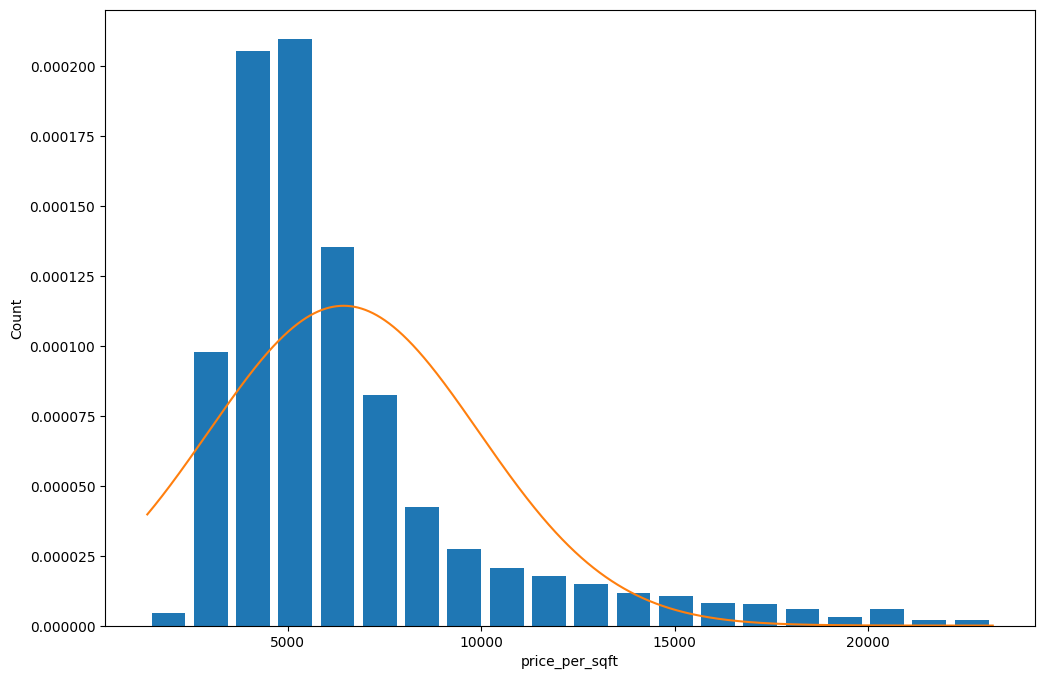

In [183]:
from matplotlib  import pyplot as plt
%matplotlib inline 
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12,8)
from scipy.stats import norm

import numpy as np

plt.hist(df1.price_per_sqft, bins = 20, rwidth = 0.8, density = True)
plt.xlabel("price_per_sqft")
plt.ylabel("Count")

rng = np.arange(df1.price_per_sqft.min(), df1.price_per_sqft.max(), 0.1)
plt.plot(rng, norm.pdf(rng, df1.price_per_sqft.mean(), df1.price_per_sqft.std()))


In [184]:
df['zscore'] = (df.price_per_sqft - df.price_per_sqft.mean())/df.price_per_sqft.std()
df.head(5)

,location,size,total_sqft,bath,price,bhk,price_per_sqft,zscore
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699,-0.715923
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615,-0.494722
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305,-0.569583
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245,-0.101099
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250,-0.582864


In [185]:
df_no_outliers = df[(df.zscore > -4) & (df.zscore < 4)]
df_no_outliers.head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft,zscore
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699,-0.715923
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615,-0.494722
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305,-0.569583
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245,-0.101099
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250,-0.582864


In [186]:
df_no_outliers.shape

(13047, 8)

In [187]:
df.shape[0] - df_no_outliers.shape[0]

125